# Mini-Project 1: Exploratory Data Analysis (EDA)
**Author:** Mohammed Anas

## Phase 1: The Detective Work (Setup & Inspection)
**Dataset Introduction:** This dataset contains retail analytics on 250 unique customers. It tracks their demographics, employment history, and purchasing behaviors. Each row represents a single unique customer's profile and their interactions with the business.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('customer_analytics.csv')

# Basic inspection
display(df.head())
display(df.info())
display(df.describe())

,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,1001,49,Male,Pune,Masters,Single,82953.0,66,23,19,9,2,Laptop,3944
1,1002,44,Male,Pune,PhD,Single,60610.0,56,22,1,23,3,Desktop,3885
2,1003,42,Male,Mumbai,Bachelors,Single,35501.0,44,18,10,29,3,Laptop,3247
3,1004,36,Female,Mumbai,Masters,Married,99312.0,36,10,12,21,3,Mobile,2028
4,1005,23,Male,Pune,Masters,Married,46980.0,56,1,18,9,3,Tablet,1100


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            255 non-null    int64  
 1   Age                   255 non-null    int64  
 2   Gender                255 non-null    object 
 3   City                  255 non-null    object 
 4   Education             243 non-null    object 
 5   MaritalStatus         255 non-null    object 
 6   AnnualIncome          243 non-null    float64
 7   SpendingScore         255 non-null    int64  
 8   YearsEmployed         255 non-null    int64  
 9   PurchaseFrequency     255 non-null    int64  
 10  OnlineVisitsPerMonth  255 non-null    int64  
 11  ReturnedItems         255 non-null    int64  
 12  PreferredDevice       255 non-null    object 
 13  LastPurchaseAmount    255 non-null    int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 28.0+ KB


None

,CustomerID,Age,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,LastPurchaseAmount
count,255.000000,255.000000,243.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.00000
mean,1126.941176,37.729412,74499.901235,45.721569,14.682353,11.568627,16.078431,1.858824,2795.07451
std,72.397256,9.767842,43939.855655,17.869522,9.651664,7.077899,7.909536,1.409917,1328.77241
min,1001.000000,21.000000,16062.000000,5.000000,1.000000,1.000000,3.000000,0.000000,566.00000
25%,1064.500000,29.000000,56353.000000,34.500000,6.000000,5.000000,10.000000,1.000000,1542.50000
50%,1128.000000,38.000000,69629.000000,47.000000,15.000000,11.000000,16.000000,2.000000,2705.00000
75%,1190.500000,46.000000,84030.500000,57.500000,23.000000,18.000000,23.000000,3.000000,4001.00000
max,1250.000000,54.000000,474327.000000,95.000000,34.000000,24.000000,29.000000,4.000000,4996.00000


## Phase 2: The Cleanup (Data Preprocessing)

**Cleaning Justifications (Rubric Requirement):**
* **Duplicates:** I found 5 duplicate rows based on `CustomerID`. I dropped them so that statistics aren't artificially skewed by the same customer being counted twice.
* **Missing Values (Annual Income):** 12 rows were missing income data. Because income has an extreme outlier ($474,327), the *mean* would be dangerously misleading. I chose to impute (fill) these missing values using the *median* ($69,629).
* **Missing Values (Education):** 12 rows were missing education. Since this is categorical data, I filled it using the *mode* (the most frequent value, which was "PhD").

In [2]:
# 1. Check for missing values & duplicates before cleaning
print("Missing values before cleaning:\n", df.isnull().sum())
print(f"Duplicates found: {df.duplicated(subset=['CustomerID']).sum()}")

# 2. Drop Duplicate Customers
df = df.drop_duplicates(subset=['CustomerID'])

# 3. Handle Missing Values
# Impute Income with Median
median_income = df['AnnualIncome'].median()
df['AnnualIncome'] = df['AnnualIncome'].fillna(median_income)

# Impute Education with Mode
mode_edu = df['Education'].mode()[0]
df['Education'] = df['Education'].fillna(mode_edu)

print("\nMissing values after cleaning:\n", df.isnull().sum())

Missing values before cleaning:
 CustomerID               0
Age                      0
Gender                   0
City                     0
Education               12
MaritalStatus            0
AnnualIncome            12
SpendingScore            0
YearsEmployed            0
PurchaseFrequency        0
OnlineVisitsPerMonth     0
ReturnedItems            0
PreferredDevice          0
LastPurchaseAmount       0
dtype: int64
Duplicates found: 5

Missing values after cleaning:
 CustomerID              0
Age                     0
Gender                  0
City                    0
Education               0
MaritalStatus           0
AnnualIncome            0
SpendingScore           0
YearsEmployed           0
PurchaseFrequency       0
OnlineVisitsPerMonth    0
ReturnedItems           0
PreferredDevice         0
LastPurchaseAmount      0
dtype: int64


## Phase 3: The Deep Dive (Univariate & Bivariate Analysis)

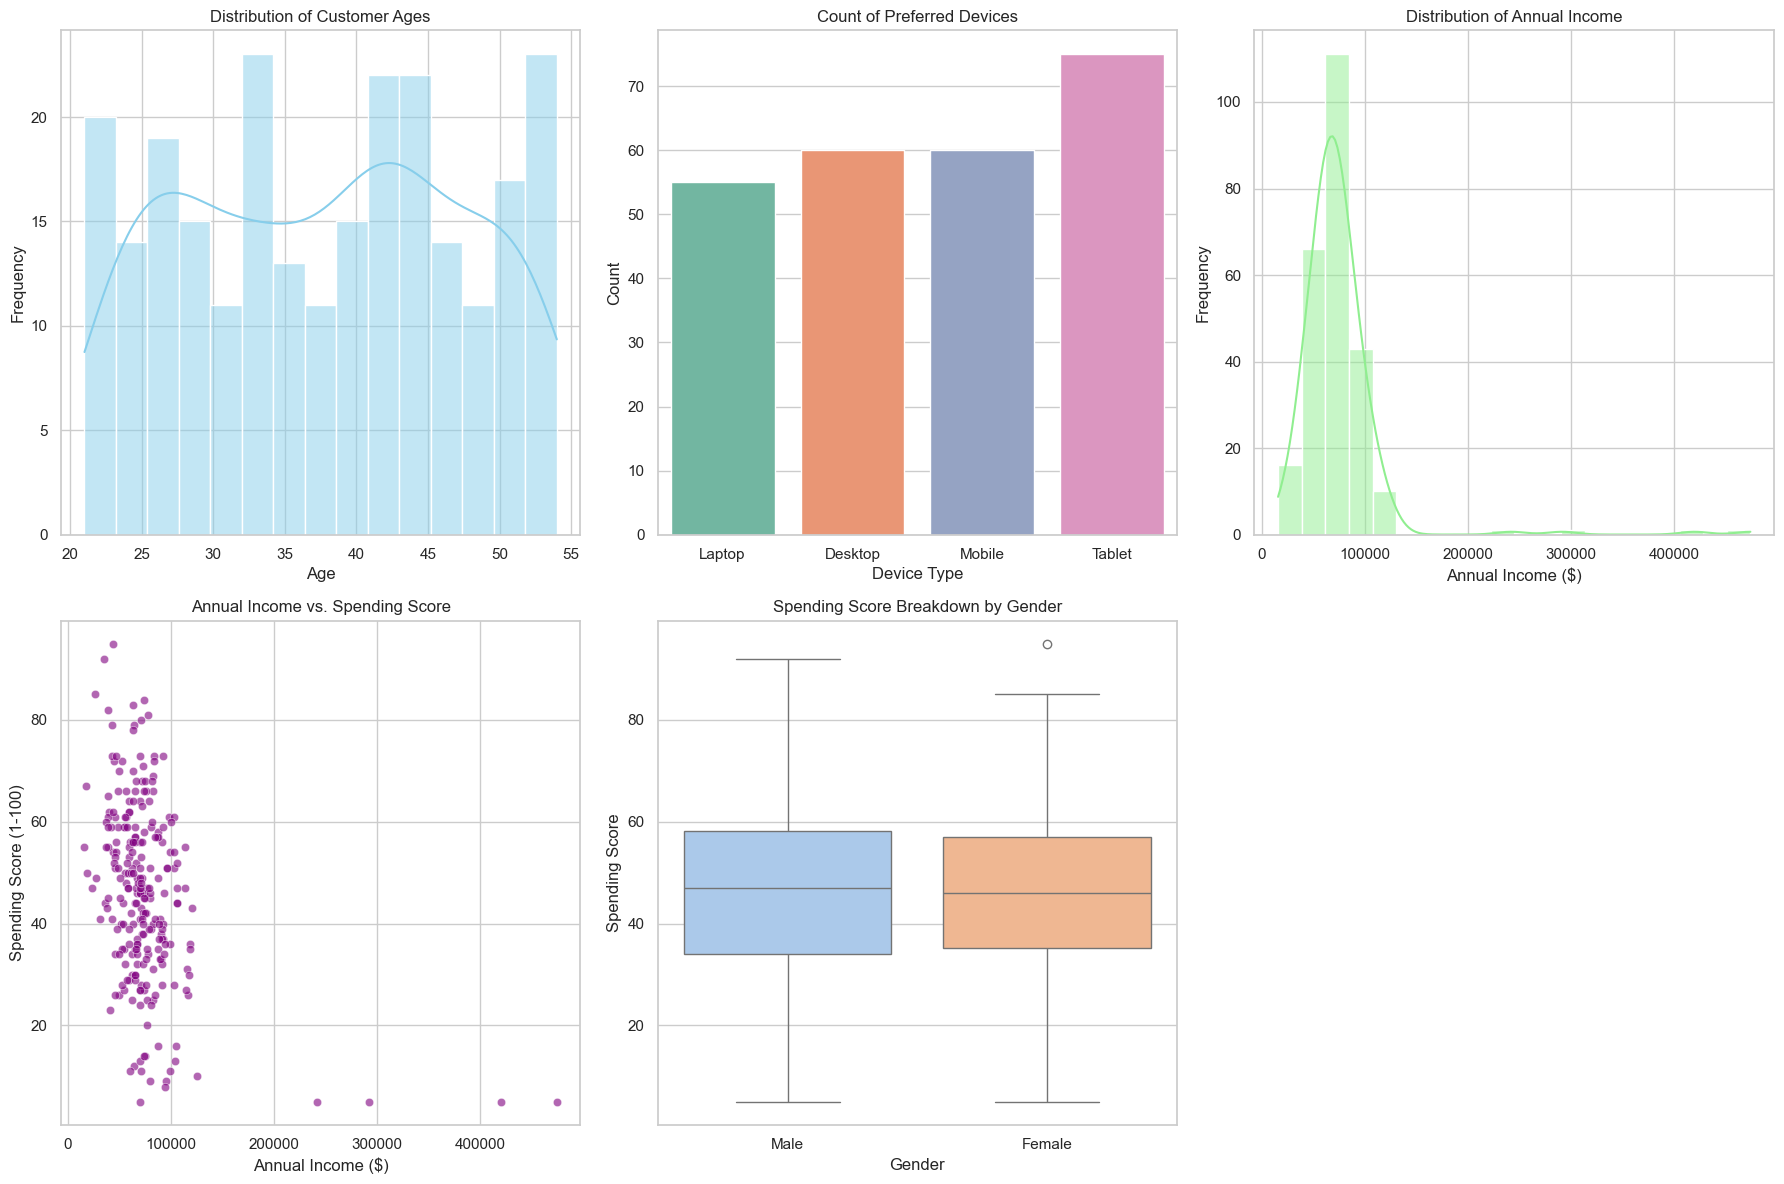

In [7]:
# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 12))

# --- Univariate Analysis ---
# Plot 1: Age Distribution
plt.subplot(2, 3, 1)
sns.histplot(df['Age'], bins=15, kde=True, color='skyblue')
plt.title('Distribution of Customer Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Plot 2: Preferred Device Bar Chart 
plt.subplot(2, 3, 2)
sns.countplot(x='PreferredDevice', data=df, hue='PreferredDevice', palette='Set2', legend=False)
plt.title('Count of Preferred Devices')
plt.xlabel('Device Type')
plt.ylabel('Count')

# Plot 3: Annual Income Distribution
plt.subplot(2, 3, 3)
sns.histplot(df['AnnualIncome'], bins=20, kde=True, color='lightgreen')
plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income ($)')
plt.ylabel('Frequency')

# --- Bivariate Analysis ---
# Plot 4: Income vs. Spending Score
plt.subplot(2, 3, 4)
sns.scatterplot(x='AnnualIncome', y='SpendingScore', data=df, color='purple', alpha=0.6)
plt.title('Annual Income vs. Spending Score')
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score (1-100)')

# Plot 5: Spending Score by Gender 
plt.subplot(2, 3, 5)
sns.boxplot(x='Gender', y='SpendingScore', data=df, hue='Gender', palette='pastel', legend=False)
plt.title('Spending Score Breakdown by Gender')
plt.xlabel('Gender')
plt.ylabel('Spending Score')

plt.tight_layout()
plt.show()

**Visual Interpretations (Rubric Requirement):**
* **Plot 1 (Age Distribution):** The customer base is relatively young to middle-aged, heavily centered around their late 30s. 
* **Plot 2 (Preferred Devices):** Tablets are surprisingly the most popular device for browsing, followed closely by Mobile. Desktops are the least preferred.
* **Plot 3 (Income Distribution):** The vast majority of customers make between $50k-$80k, but there is a massive positive skew caused by at least one extreme high-earner outlier making over $400k.
* **Plot 4 (Income vs. Spending):** Interestingly, there is a visible negative trend! Customers with lower incomes actually tend to have higher spending scores. 
* **Plot 5 (Score by Gender):** The boxplot shows that the median spending score is nearly identical between males and females, indicating gender does not strongly influence spending behavior.

## Phase 4: The Big Picture (Multivariate & Storytelling)

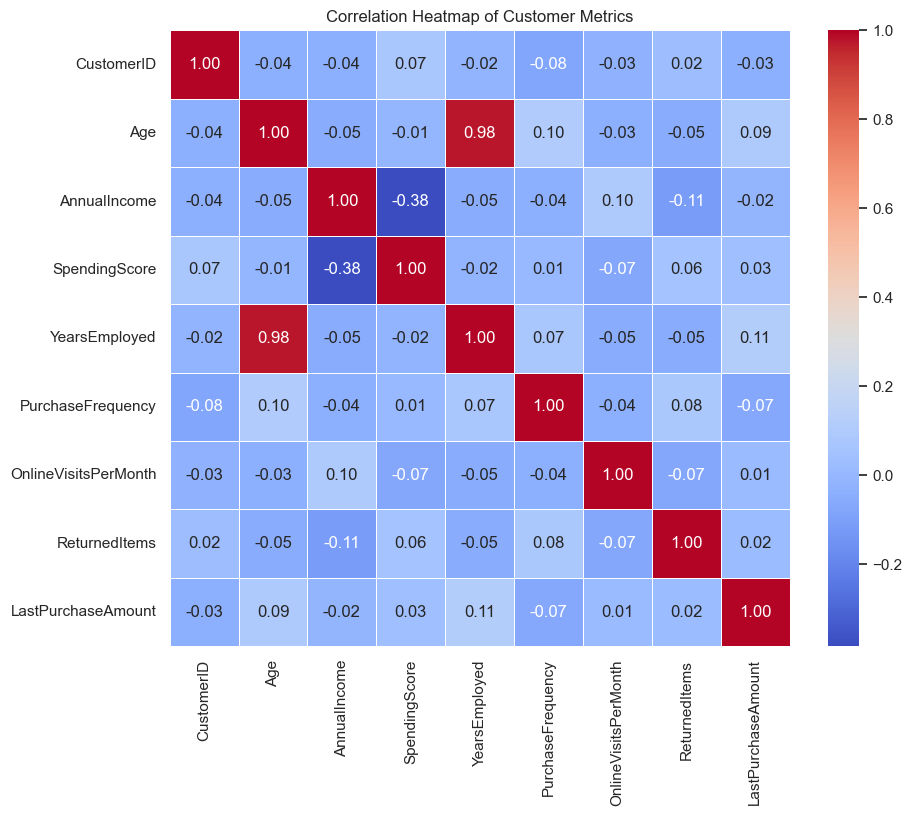

In [8]:
# Correlation Matrix & Heatmap
# Select only numerical columns for the matrix
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Customer Metrics")
plt.show()

### Executive Summary
Based on my exploratory data analysis, here are the top 3 actionable insights:
1. **The "Frugal High-Earner" Anomaly:** The correlation heatmap reveals a notable negative correlation (-0.38) between `AnnualIncome` and `SpendingScore`. Paradoxically, our wealthiest customers are spending the least amount of money on the platform. We need targeted premium campaigns to engage high-earners.
2. **Age Predicts Career Length Perfectly:** There is an near-perfect positive correlation (+0.98) between `Age` and `YearsEmployed`. This suggests our customer demographic consists of people with highly stable, lifelong careers rather than job-hoppers.
3. **Mobile-First Strategy Needed:** Tablet and Mobile entirely dominate the `PreferredDevice` category. Any future UI/UX updates or marketing campaigns must be strictly optimized for touch-screen devices, as Desktop users make up the minority of our traffic.